In [ ]:
# Load datasets
n = 1
while n < 2:
  from google.colab import files
  uploaded = files.upload()  # Opens a file upload prompt
  n += 1

Saving lipid_boxplot_data_long.csv to lipid_boxplot_data_long.csv


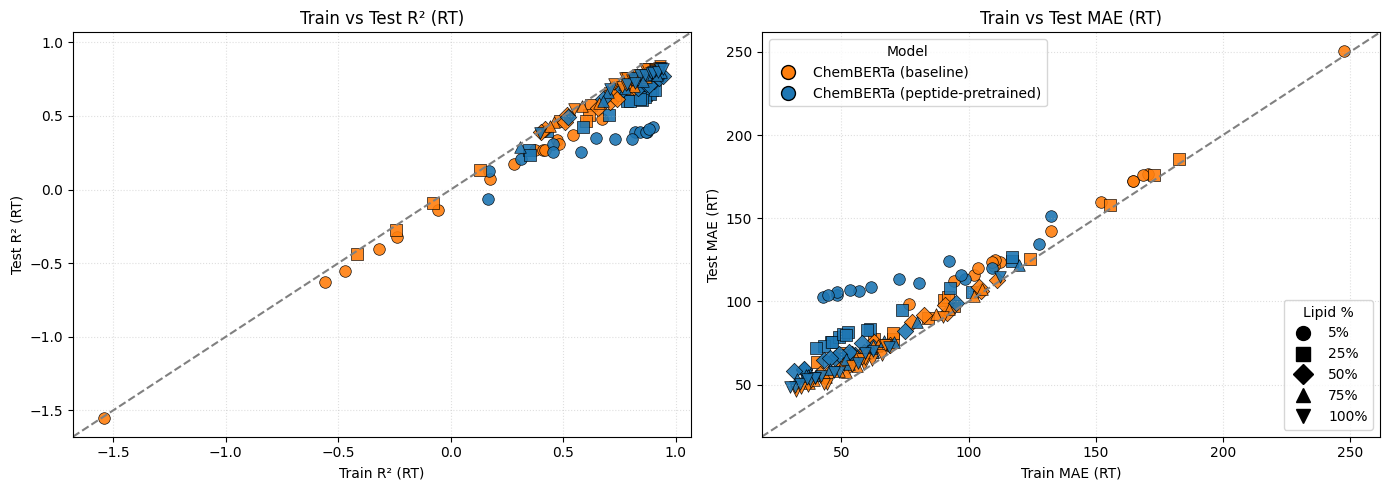

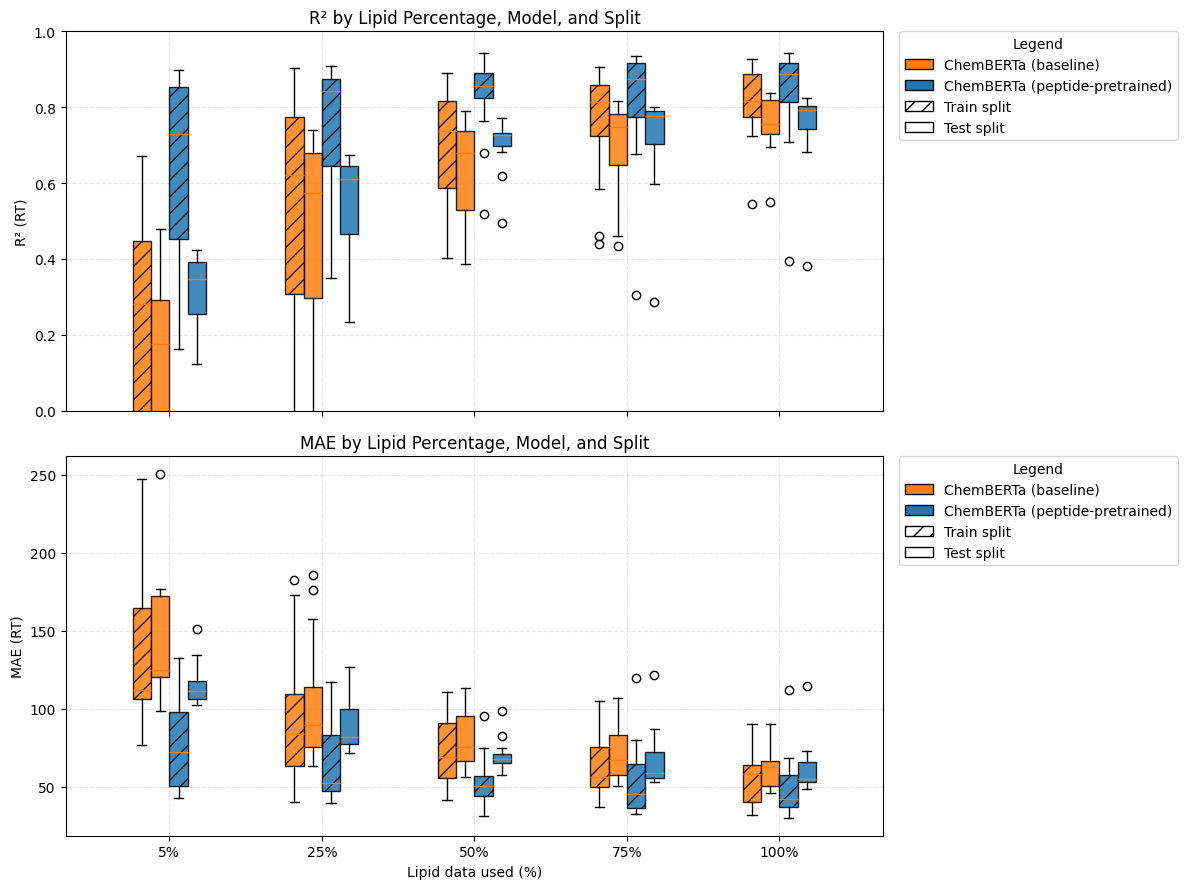

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ============================================================
# 1) LOAD DATA
# ============================================================

df = pd.read_csv("lipid_boxplot_data_long.csv")

# Pivot wide for scatter usage
wide = (
    df.pivot_table(
        index=["percentage", "model", "epoch", "metric"],
        columns="split",
        values="value"
    )
    .reset_index()
)

metrics = ["R2", "MAE"]
metric_labels = {"R2": "R² (RT)", "MAE": "MAE (RT)"}

percentages = sorted(df["percentage"].unique())
models = ["Baseline", "Transfer"]
splits = ["Train", "Test"]

# ============================================================
# 2) COLOR / LABEL SETTINGS
# ============================================================

model_colors = {
    "Baseline": "#ff7f0e",  # ORANGE
    "Transfer": "#1f77b4",  # BLUE
}

model_legend_labels = {
    "Baseline": "ChemBERTa (baseline)",
    "Transfer": "ChemBERTa (peptide-pretrained)"
}

# marker per % lipid
marker_list = ["o", "s", "D", "^", "v", "<", ">", "P", "X"]
marker_map = {p: marker_list[i % len(marker_list)] for i, p in enumerate(percentages)}

split_hatch = {"Train": "//", "Test": ""}

# ============================================================
# 3) SCATTERPLOTS (Train vs Test)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, metrics):

    sub = wide[wide["metric"] == metric]

    vals = sub[["Train", "Test"]].to_numpy().ravel()
    vmin, vmax = vals.min(), vals.max()
    pad = (vmax - vmin) * 0.05
    lim_min, lim_max = vmin - pad, vmax + pad

    for _, row in sub.iterrows():
        pct = row["percentage"]
        model = row["model"]

        ax.scatter(
            row["Train"], row["Test"],
            color=model_colors[model],
            marker=marker_map[pct],
            s=70, alpha=0.9,
            edgecolor="black", linewidth=0.5
        )

    ax.plot([lim_min, lim_max], [lim_min, lim_max], "--", color="gray")
    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)

    ax.set_xlabel(f"Train {metric_labels[metric]}")
    ax.set_ylabel(f"Test {metric_labels[metric]}")
    ax.set_title(f"Train vs Test {metric_labels[metric]}")
    ax.grid(True, linestyle=":", alpha=0.4)

# Model legend
model_handles = [
    plt.Line2D([0], [0], marker='o', color='white',
               markerfacecolor=model_colors[m], markeredgecolor='black',
               label=model_legend_labels[m], markersize=10)
    for m in models
]

# % Lipid marker legend
pct_handles = [
    plt.Line2D([0], [0], marker=marker_map[p], linestyle='None',
               color='black', label=f"{p}%", markersize=10)
    for p in percentages
]

legend1 = axes[1].legend(handles=model_handles, title="Model", loc="upper left")
axes[1].add_artist(legend1)
axes[1].legend(handles=pct_handles, title="Lipid %", loc="lower right")

plt.tight_layout()
plt.show()


# ============================================================
# 4) BOXPLOTS (Train + Test for each % and model)
# ============================================================

r2_df  = df[df["metric"] == "R2"]
mae_df = df[df["metric"] == "MAE"]
percentages_sorted = percentages
x = np.arange(len(percentages_sorted))
box_width = 0.12

fig, (ax_r2, ax_mae) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

def add_metric_boxplot(ax, metric_df, ylabel, title):

    data_list = []
    pos_list = []
    color_list = []
    hatch_list = []

    offsets = {
        ("Baseline", "Train"): -1.5 * box_width,
        ("Baseline", "Test"):  -0.5 * box_width,
        ("Transfer", "Train"):  0.5 * box_width,
        ("Transfer", "Test"):   1.5 * box_width,
    }

    for i, p in enumerate(percentages_sorted):
        for model in models:
            for split in splits:

                vals = metric_df[
                    (metric_df["percentage"] == p) &
                    (metric_df["model"] == model) &
                    (metric_df["split"] == split)
                ]["value"].values

                if len(vals) == 0:
                    continue

                pos_list.append(x[i] + offsets[(model, split)])
                data_list.append(vals)
                color_list.append(model_colors[model])
                hatch_list.append(split_hatch[split])

    bp = ax.boxplot(
        data_list,
        positions=pos_list,
        widths=box_width,
        patch_artist=True
    )

    for box, c, h in zip(bp['boxes'], color_list, hatch_list):
        box.set_facecolor(c)
        box.set_hatch(h)
        box.set_alpha(0.85)

    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, linestyle='--', alpha=0.3)

    # Create legend (outside plot)
    model_handles = [
        Patch(facecolor=model_colors[m], edgecolor='black',
              label=model_legend_labels[m])
        for m in models
    ]
    split_handles = [
        Patch(facecolor='white', edgecolor='black',
              hatch=split_hatch[s], label=f"{s} split")
        for s in splits
    ]

    combined_handles = model_handles + split_handles
    combined_labels = (
        [model_legend_labels[m] for m in models] +
        [f"{s} split" for s in splits]
    )

    ax.legend(
        combined_handles,
        combined_labels,
        bbox_to_anchor=(1.02, 1),  # right outside
        loc='upper left',
        borderaxespad=0.,
        title="Legend"
    )

# ---- Apply to both metrics ----

add_metric_boxplot(
    ax_r2,
    r2_df,
    ylabel="R² (RT)",
    title="R² by Lipid Percentage, Model, and Split"
)
ax_r2.set_ylim(0, 1)

add_metric_boxplot(
    ax_mae,
    mae_df,
    ylabel="MAE (RT)",
    title="MAE by Lipid Percentage, Model, and Split"
)

ax_mae.set_xticks(x)
ax_mae.set_xticklabels([f"{p}%" for p in percentages_sorted])
ax_mae.set_xlabel("Lipid data used (%)")

plt.tight_layout()
plt.show()